In [1]:
import torch
from matplotlib import pyplot as plt

In [3]:
def euclid_norm_vec(x):
    return torch.sqrt(torch.dot(x, x))


def euclid_norm_tensor(X):
    return torch.sqrt(torch.sum(X * X, dim=1))

In [4]:
U = torch.linspace(-1, 1, 50, device=torch.device("cpu"))
B = torch.cartesian_prod(U, U)
B = B[euclid_norm_tensor(B) < 1]

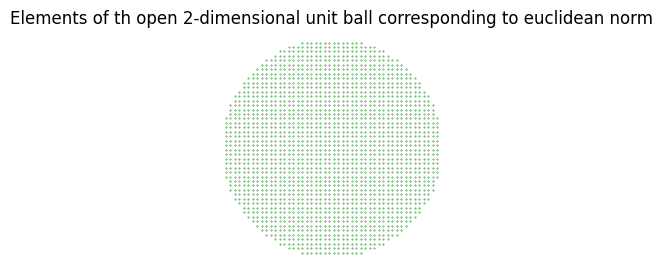

In [5]:
plt.figure(figsize=(3, 3))
plt.scatter(B[:, 0].cpu(), B[:, 1].cpu(), color="green", s=0.1)
plt.axis("off")
plt.title("Elements of th open 2-dimensional unit ball corresponding to euclidean norm")
plt.show()

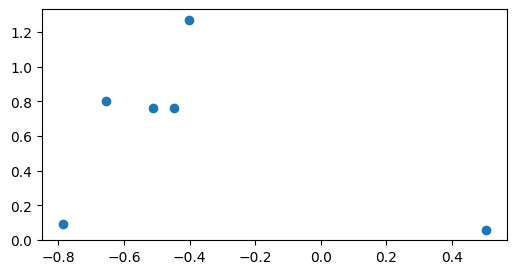

In [6]:
# create points on lobachevsky half plane
H = torch.randn(6, dtype=torch.cfloat)
for c in H:
    if c.imag <= 0:
        c.imag *= -1

plt.figure(figsize=(6, 3))
plt.scatter(H.real, H.imag)
plt.show()

In [7]:
# transform points to poincare disk (Cayley transform)
def cayley(z):
    return (z - torch.complex(torch.zeros(1), torch.ones(1))) / (
        z + torch.complex(torch.zeros(1), torch.ones(1))
    )

def cayley_inverse(z):
    return 0+1j * ((1 + z) / (1 - z))

In [8]:
def circ_plus(a, z):
    return (a + z) / (1 + a.conj() * z)


def circ_minus(a, z):
    return circ_plus(a, -z)


def circ_times(v, t):
    return (
        ((1 + v.abs()) ** t - (1 - v.abs()) ** t)
        / ((1 + v.abs()) ** t + (1 - v.abs()) ** t)
    ) * (v / v.abs())


def geodesic_D(z1, z2, t):
    return circ_plus(z1, circ_times(circ_plus(-z1, z2), t))

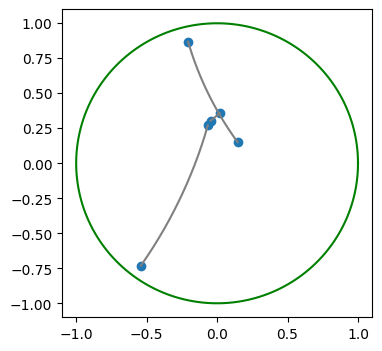

In [9]:
D = torch.vmap(cayley)(H)
theta = torch.linspace(0, 2 * torch.pi, 200)
t = torch.linspace(0, 1, 1000)
geodesic_0_1_D = torch.vmap(geodesic_D, in_dims=(None, None, 0))(D[0], D[1], t)
geodesic_2_3_D = torch.vmap(geodesic_D, in_dims=(None, None, 0))(D[2], D[3], t)
geodesic_4_5_D = torch.vmap(geodesic_D, in_dims=(None, None, 0))(D[4], D[5], t)

plt.figure(figsize=(4, 4))
plt.plot(torch.cos(theta), torch.sin(theta), c="g")
plt.plot(geodesic_0_1_D.real, geodesic_0_1_D.imag, c="grey")
plt.plot(geodesic_2_3_D.real, geodesic_2_3_D.imag, c="grey")
plt.plot(geodesic_4_5_D.real, geodesic_4_5_D.imag, c="grey")
plt.scatter(D.real, D.imag)
plt.show()

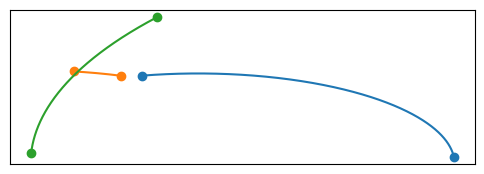

In [10]:
geodesic_0_1_H = torch.vmap(cayley_inverse)(geodesic_0_1_D)
geodesic_2_3_H = torch.vmap(cayley_inverse)(geodesic_2_3_D)
geodesic_4_5_H = torch.vmap(cayley_inverse)(geodesic_4_5_D)

plt.figure(figsize=(6, 2))
plt.xticks([])
plt.yticks([])
plt.scatter(H[0:2].real, H[0:2].imag)
plt.scatter(H[2:4].real, H[2:4].imag)
plt.scatter(H[4:6].real, H[4:6].imag)
plt.plot(geodesic_0_1_H.real, geodesic_0_1_H.imag)
plt.plot(geodesic_2_3_H.real, geodesic_2_3_H.imag)
plt.plot(geodesic_4_5_H.real, geodesic_4_5_H.imag)
plt.savefig("lobackevsky_geodesics.png")
plt.show()

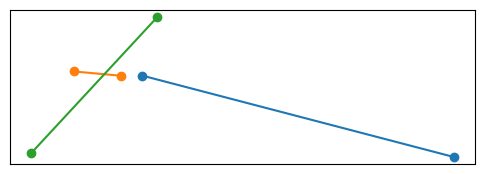

In [11]:
plt.figure(figsize=(6, 2))
plt.xticks([])
plt.yticks([])
plt.scatter(H[0:2].real, H[0:2].imag)
plt.scatter(H[2:4].real, H[2:4].imag)
plt.scatter(H[4:6].real, H[4:6].imag)
plt.plot(H[0:2].real, H[0:2].imag)
plt.plot(H[2:4].real, H[2:4].imag)
plt.plot(H[4:6].real, H[4:6].imag)
plt.savefig("euclidean_geodesics.png")
plt.show()

In [25]:
# check that distances stay correct after transform
def dist_H(z1, z2):
    return torch.log(
        ((z1 - z2.conj()).abs() + (z1 - z2).abs())
        / ((z1 - z2.conj()).abs() - (z1 - z2).abs())
    )


def dist_D(w1, w2):
    return torch.log(
        ((1 - w1 * w2.conj()).abs() + (w1 - w2).abs())
        / ((1 - w1 * w2.conj()).abs() - (w1 - w2).abs())
    )

In [26]:
# compare distances
distance_H = dist_H(H[0], H[1])
distance_D = dist_D(D[0], D[1])
print(distance_H.item())
print(distance_D.item())

3.4834706783294678
3.4834699630737305


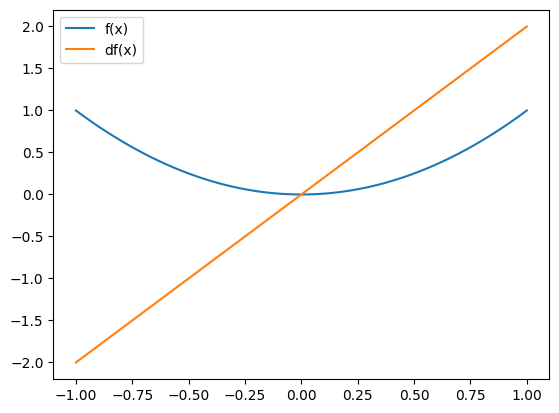

In [27]:
# test autodiff
def f(x):
    return x**2

X = torch.linspace(-1, 1, 100, requires_grad=True)
f_X = f(X)

f_X.backward(torch.ones_like(X))

plt.plot(X.detach().numpy(), f_X.detach().numpy(), label="f(x)")
plt.plot(X.detach().numpy(), X.grad.detach().numpy(), label="df(x)")
plt.legend()
plt.show()